In [10]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import os
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from PIL import Image
import squarify
# import scipy

In [3]:
data_dir = "/Users/z5116060/Desktop/GitProjects/hearing/data"

# Warehouse data (linked with Hearing Australia audiometry)

The following cells compute descriptive statistics and basic plots regarding demographics for the patients that were linked with Hearing Australia and had a 3FAHL > 20.

/var/folders/54/zjqr9dnn37l3lz5w31phlfch0000gq/T/ipykernel_10858/1908554264.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['GENDER_TEXT'] = filtered_df['GENDER_TEXT'].astype('category')


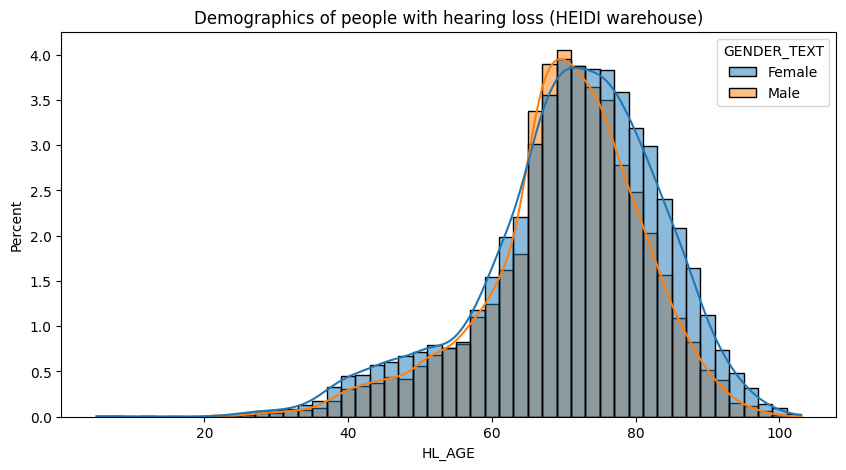

In [4]:
# 1. Demographics of people with hearing loss (HEIDI warehouse)

patron_hl_data = pd.read_csv(os.path.join(data_dir,'audiogram_HL_demographics.csv'))
filtered_df = patron_hl_data[patron_hl_data['GENDER_TEXT'] != 'Not Recorded']
plt.figure(figsize=(10, 5))
sn.histplot(data=filtered_df, x='HL_AGE', hue='GENDER_TEXT', kde=True, binwidth=2, stat='percent')
plt.title('Demographics of people with hearing loss (HEIDI warehouse)')
filtered_df['GENDER_TEXT'] = filtered_df['GENDER_TEXT'].astype('category')

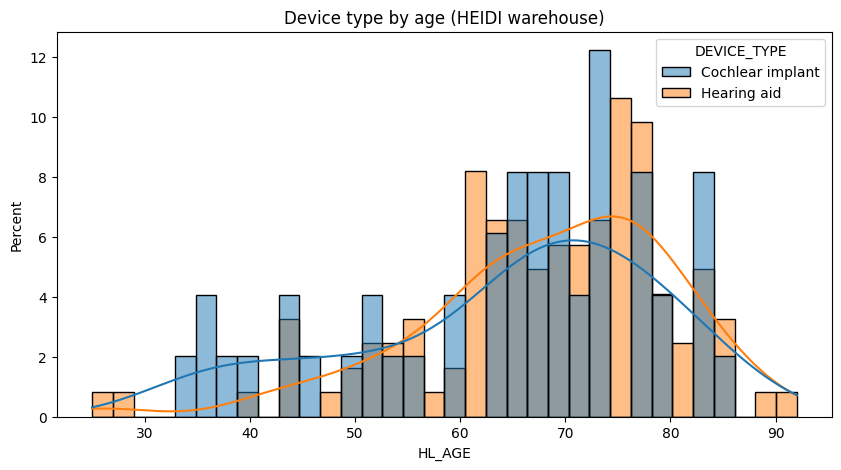

In [5]:
# 2. Device type by age (HEIDI warehouse)

patron_hl_data = pd.read_csv(os.path.join(data_dir,'audiogram_HL_demographics.csv'))

plt.figure(figsize=(10, 5))
sn.histplot(data=patron_hl_data, x='HL_AGE', hue='DEVICE_TYPE', kde=True, binwidth=2, stat='percent', common_norm=False)
plt.title('Device type by age (HEIDI warehouse)')
patron_hl_data['DEVICE_TYPE'] = patron_hl_data['DEVICE_TYPE'].astype('category')

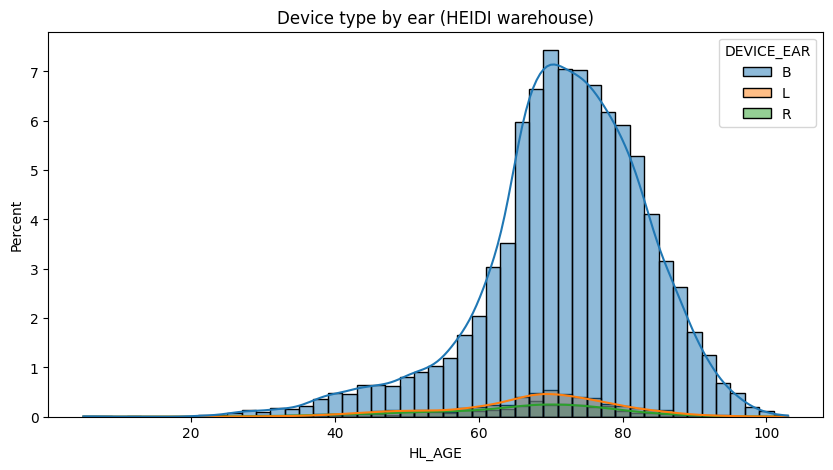

In [6]:
# 3. Device type by ear (HEIDI warehouse)
patron_hl_data = pd.read_csv(os.path.join(data_dir,'audiogram_HL_demographics.csv'))

plt.figure(figsize=(10, 5))
sn.histplot(data=patron_hl_data, x='HL_AGE', hue='DEVICE_EAR', kde=True, binwidth=2, stat='percent')
plt.title('Device type by ear (HEIDI warehouse)')
patron_hl_data['DEVICE_EAR'] = patron_hl_data['DEVICE_EAR'].astype('category')

Text(0.5, 1.0, 'Initial 3FAHL Right vs Age')

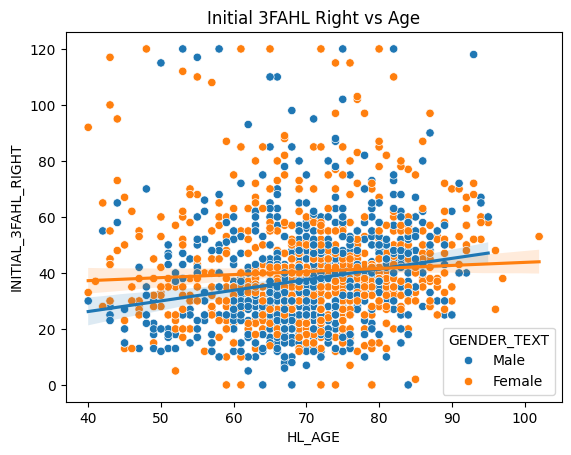

In [7]:
# 4. Inital 3FAHL Right vs Age
frank_patron_hl_data = pd.read_csv(os.path.join(data_dir,'frank_audiogram.csv'))
sampled_data = frank_patron_hl_data.sample(frac=0.1, random_state=1)

sn.scatterplot(data=sampled_data, x='HL_AGE', y='INITIAL_3FAHL_RIGHT', hue='GENDER_TEXT')

# Regression lines for each group
groups = sampled_data['GENDER_TEXT'].unique()
for group in groups:
    sn.regplot(y='INITIAL_3FAHL_RIGHT', x='HL_AGE', data=sampled_data[sampled_data['GENDER_TEXT'] == group], scatter=False, label=f'Group {group}')

plt.title('Initial 3FAHL Right vs Age')

Text(0.5, 1.0, 'Initial 3FAHL Left vs Age')

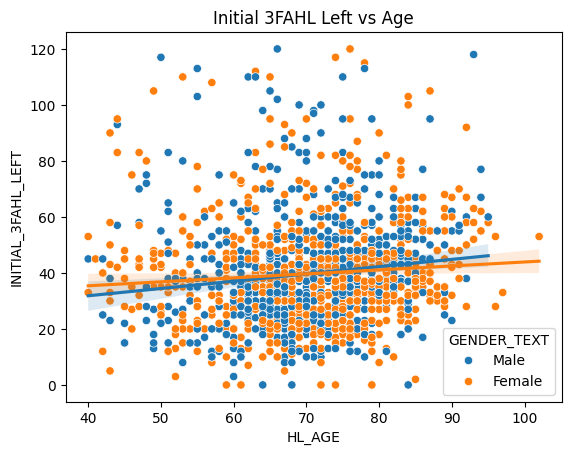

In [8]:
# 5. Inital 3FAHL Left vs Age
frank_patron_hl_data = pd.read_csv(os.path.join(data_dir,'frank_audiogram.csv'))
sampled_data = frank_patron_hl_data.sample(frac=0.1, random_state=1)

sn.scatterplot(data=sampled_data, y='INITIAL_3FAHL_LEFT', x='HL_AGE', hue='GENDER_TEXT')

# Regression lines for each group
groups = sampled_data['GENDER_TEXT'].unique()
for group in groups:
    sn.regplot(y='INITIAL_3FAHL_LEFT', x='HL_AGE', data=sampled_data[sampled_data['GENDER_TEXT'] == group], scatter=False, label=f'Group {group}')

plt.title('Initial 3FAHL Left vs Age')

<Axes: xlabel='FAHL3_LEFT', ylabel='HL_AGE'>

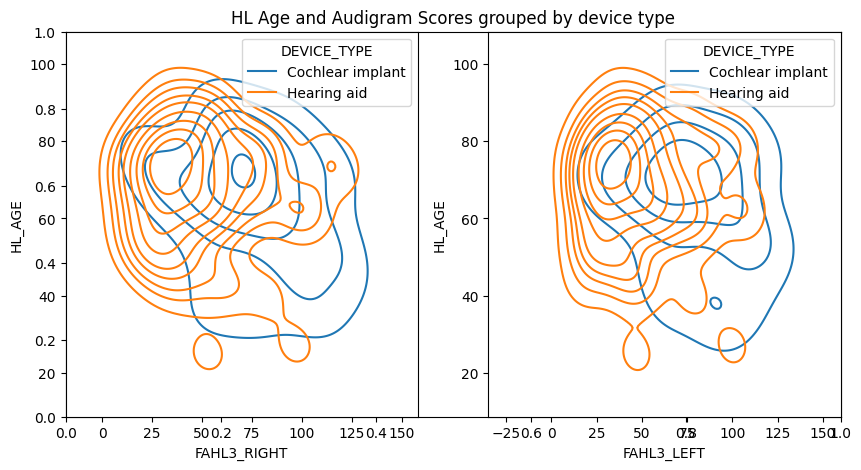

In [9]:
# 6 HL Age and Audigram Scores grouped by device type
patron_hl_data = pd.read_csv(os.path.join(data_dir,'audiogram_HL_demographics.csv'))
plt.figure(figsize=(10, 5))
plt.title('HL Age and Audigram Scores grouped by device type')
plt.subplot(1, 2, 1)
sn.kdeplot(data=patron_hl_data, x='FAHL3_RIGHT', y='HL_AGE', hue='DEVICE_TYPE')
plt.title('')
plt.subplot(1, 2, 2)
sn.kdeplot(data=patron_hl_data, x='FAHL3_LEFT', y='HL_AGE', hue='DEVICE_TYPE')

In [10]:
# 7 Descriptive Statistics Grouped By Gender
patron_hl_data = pd.read_csv(os.path.join(data_dir,'audiogram_HL_demographics.csv'))
warnings.simplefilter(action='ignore', category=FutureWarning)
patron_hl_data.set_index('PATIENT_ID').groupby('GENDER_TEXT').describe()

HL_AGE                                                       \
                count       mean        std   min   25%   50%   75%    max   
GENDER_TEXT                                                                  
Female        11846.0  70.804322  12.655771   5.0  64.0  72.0  79.0  103.0   
Male           9851.0  69.743173  11.231185   8.0  65.0  71.0  77.0  102.0   
Not Recorded      5.0  56.000000  14.560220  37.0  50.0  53.0  65.0   75.0   

             FAHL3_LEFT             ... L_4000          R_4000             \
                  count       mean  ...    75%    max    count       mean   
GENDER_TEXT                         ...                                     
Female          11846.0  39.239490  ...   65.0  120.0  11846.0  51.604339   
Male             9851.0  38.944574  ...   75.0  120.0   9851.0  62.231246   
Not Recorded        5.0  47.600000  ...   65.0   70.0      5.0  45.000000   

                                                        
                    std   min   25%   50%   75%    max  
GENDER_TEXT                                             
Female        21.805744  -5.0  35.0  50.0  65.0  120.0  
Male          20.602492   0.0  50.0  60.0  75.0  120.0  
Not Recorded  13.693064  30.0  35.0  45.0  50.0   65.0  

[3 rows x 104 columns]

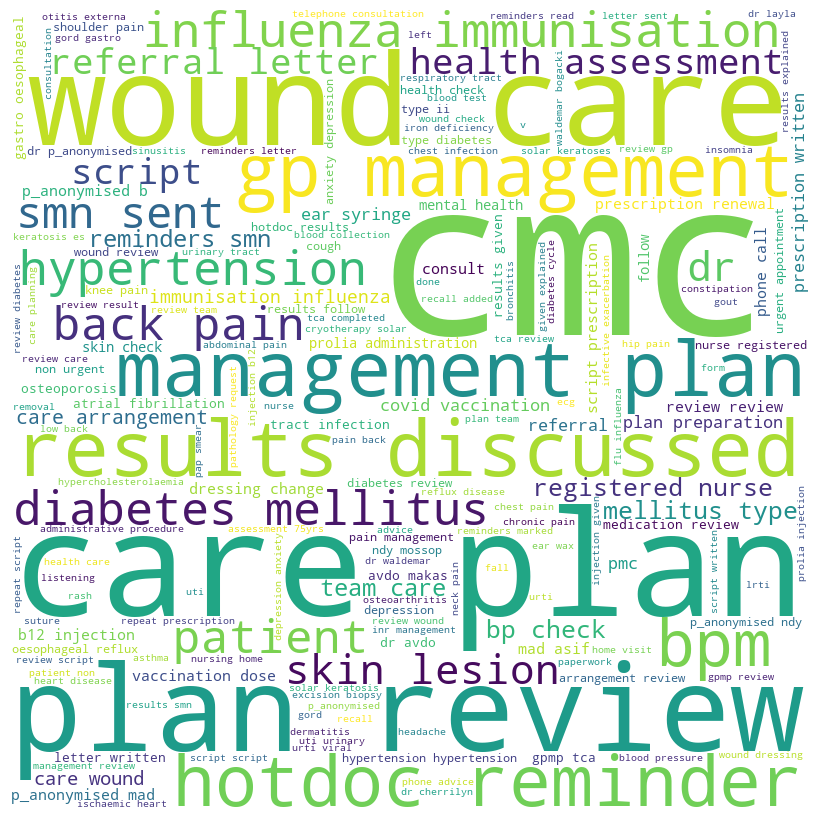

In [ ]:
# 14 VisitReasons WordCloud v1

df = pd.read_csv(os.path.join(data_dir, "visit_reasons_before_hl.csv"), encoding ="latin-1", header=None, names=['reasons'])

comment_words = ''
stopwords = set(STOPWORDS)

# iterate through the csv file
for val in df['reasons']:

    # typecaste each val to string
    val = str(val)

    # split the value
    tokens = val.split()

    # Converts each token into lowercase
    for i in range(len(tokens)):
        tokens[i] = tokens[i].lower()

    comment_words += " ".join(tokens)+" "

wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                stopwords = stopwords,
                min_font_size = 10).generate(comment_words)

# plot the WordCloud image
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()


4300951 713395


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

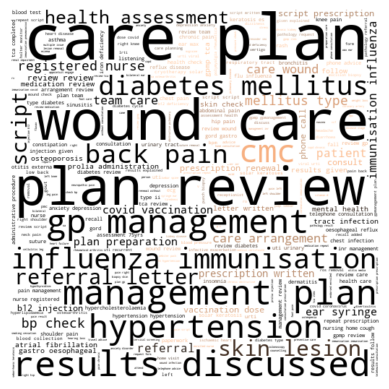

In [ ]:
# 15 VisitReasons WordCloud v2

df = pd.read_csv(os.path.join(data_dir, "visit_reasons_before_hl.csv"), encoding ="latin-1", header=None, names=['reasons'])
heidi_coloring = np.array(Image.open(os.path.join(data_dir,"ear.png")))
comment_words = ''
stopwords = set(STOPWORDS)
 
# iterate through the csv file
for row in df['reasons']:
 
    # print(row)
    # split the value
    tokens = str(row).split(' ')
    # Converts each token into lowercase
    for i in range(len(tokens)):
        tokens[i] = tokens[i].lower()
 
    if 'p_anonym' in " ".join(tokens)+" " or 'hotdoc' in " ".join(tokens)+" " or 'dr' in " ".join(tokens)+" ":
        continue
    comment_words += " ".join(tokens)+" "
 
print(len(comment_words), len(comment_words.split(' ')))
wc = WordCloud(
    background_color ='white',
    max_words=2000,
    mask = heidi_coloring,
    stopwords = stopwords,
    contour_width=3,
    # min_font_size = 5
)
 
# generate word cloud
wc.generate(comment_words)
 
# create coloring from image
image_colors = ImageColorGenerator(heidi_coloring)
 
# show
plt.figure()
plt.imshow(wc.recolor(color_func=image_colors), interpolation="bilinear")
plt.axis('off')
 

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

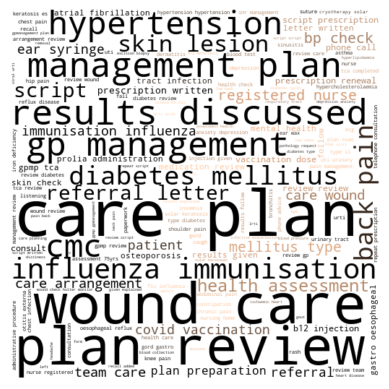

In [24]:
# 16 VisitReasons WordCloud v3
wc = WordCloud(
    width = 800, height = 800,
    background_color ='white',
    stopwords = stopwords,
    mask = heidi_coloring,
    contour_width=10,
    min_font_size = 5
)
 
# generate word cloud
wc.generate(comment_words)
 
# create coloring from image
image_colors = ImageColorGenerator(heidi_coloring)
 
# show
plt.figure()
plt.imshow(wc.recolor(color_func=image_colors), interpolation="bilinear")
plt.axis('off')

# Specsavers

In [ ]:
# 8 Specsavers AU and NZ Age Range

au_data = pd.read_csv(os.path.join(data_dir,'AU_screeners_data.csv'))
nz_data = pd.read_csv(os.path.join(data_dir,'NZ_screeners_data.csv'))

au_ages = au_data.assign(
    age=pd.to_numeric(au_data['testDateTime'].str[-4:]) - pd.to_numeric(au_data['birthday']).to_numpy()
)
nz_ages = nz_data.assign(
    age=pd.to_numeric(nz_data['testDateTime'].str[-4:]) - pd.to_numeric(nz_data['birthday']).to_numpy()
)

min_au = np.min(au_ages['age'])
max_au = np.max(au_ages['age'])
min_nz = np.min(nz_ages['age'])
max_nz = np.max(nz_ages['age'])

print(f'AU participants: {len(au_ages)} [{min_au} - {max_au}]')
print(f'NZ participants {len(nz_ages)} [{min_nz} - {max_nz}]')

print(f'All participants {len(au_ages) + len(nz_ages)}')

In [ ]:
# 9 General demographics of SpecSavers participants (Australia)
au_data = pd.read_csv(os.path.join(data_dir,'AU_screeners_data.csv'))
au_ages = au_data.assign(
    age=pd.to_numeric(au_data['testDateTime'].str[-4:]) - pd.to_numeric(au_data['birthday']).to_numpy()
)
plt.figure(figsize=(10, 5))
sn.histplot(data=au_ages, x='age', kde=True, stat='percent', binwidth=2)
plt.title('General demographics of SpecSavers participants (Australia)')

In [ ]:
# 10 General demographics of SpecSavers participants (Australia) with 3FAHL > 20dB
au_data = pd.read_csv(os.path.join(data_dir,'AU_screeners_data.csv'))
au_ages = au_data.assign(
    age=pd.to_numeric(au_data['testDateTime'].str[-4:]) - pd.to_numeric(au_data['birthday']).to_numpy()
)
au_fahl = au_ages.assign(
    fahl3Left=(
        (
            pd.to_numeric(au_ages['hlLeft.freq500']) +
            pd.to_numeric(au_ages['hlLeft.freq1000']) +
            pd.to_numeric(au_ages['hlLeft.freq2000'])
        ) / 3
    ).to_numpy()
)
au_fahl = au_fahl.assign(
    fahl3Right=(
        (
            pd.to_numeric(au_ages['hlRight.freq500']) +
            pd.to_numeric(au_ages['hlRight.freq1000']) +
            pd.to_numeric(au_ages['hlRight.freq2000'])
        ) / 3
    ).to_numpy()
)

spec_au_hl = au_fahl[(au_fahl['fahl3Right'] > 20) | (au_fahl['fahl3Left'] > 20)]

print('People with hearing loss {:5.2f}% (SpecSavers Australia)'.format(100 * len(spec_au_hl) / len(au_fahl)))

plt.figure(figsize=(10, 5))
sn.histplot(data=spec_au_hl, x='age', kde=True, stat='percent', binwidth=2)
plt.title('General demographics of SpecSavers participants (Australia) with 3FAHL > 20dB')

In [ ]:
# 11 Demographics of Specsaver entries with hearing loss
au_fahl = au_ages.assign(
    fahl3Left=(
        (
            pd.to_numeric(au_ages['hlLeft.freq500']) +
            pd.to_numeric(au_ages['hlLeft.freq1000']) +
            pd.to_numeric(au_ages['hlLeft.freq2000'])
        ) / 3
    ).to_numpy()
)
au_fahl = au_fahl.assign(
    fahl3Right=(
        (
            pd.to_numeric(au_ages['hlRight.freq500']) +
            pd.to_numeric(au_ages['hlRight.freq1000']) +
            pd.to_numeric(au_ages['hlRight.freq2000'])
        ) / 3
    ).to_numpy()
)

spec_au_hl = au_fahl[(au_fahl['fahl3Right'] > 20) | (au_fahl['fahl3Left'] > 20)]

spec_demo = spec_au_hl.loc[:, 
    ~spec_au_hl.columns.str.contains('freq') &
    ~spec_au_hl.columns.str.contains('birthday') &
    ~spec_au_hl.columns.str.contains('Date')
]
filt_spec_demo = spec_demo[spec_demo['age'] > 45]

filt_spec_demo.describe()

In [ ]:
# 12 Age range of Specsaver entries with hearing loss
range_spec_demo = filt_spec_demo.assign(
    age=filt_spec_demo['age'] // 10 * 10
)
range_spec_demo.groupby('age').describe()

In [ ]:
# 13 Specsavers Jitter 3FAHL Right by Age
jitter_right = filt_spec_demo.assign(
    jfahl3Right=filt_spec_demo['fahl3Right'] + np.random.rand(len(filt_spec_demo)) * 3
)
jitter_right = jitter_right.assign(
    jage=filt_spec_demo['age'] + np.random.rand(len(filt_spec_demo)) * 5
)
jitter_left = filt_spec_demo.assign(
    jfahl3Left=filt_spec_demo['fahl3Left'] + np.random.rand(len(filt_spec_demo)) * 3
)
jitter_left = jitter_left.assign(
    jage=filt_spec_demo['age'] + np.random.rand(len(filt_spec_demo)) * 5
)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sn.histplot(data=jitter_right, x='jage', y='jfahl3Right')
plt.title('3FAHL right by age')
plt.subplot(1, 2, 2)
sn.histplot(data=jitter_left, x='jage', y='jfahl3Left')
plt.title('3FAHL right by age')

(20.0, 100.0)

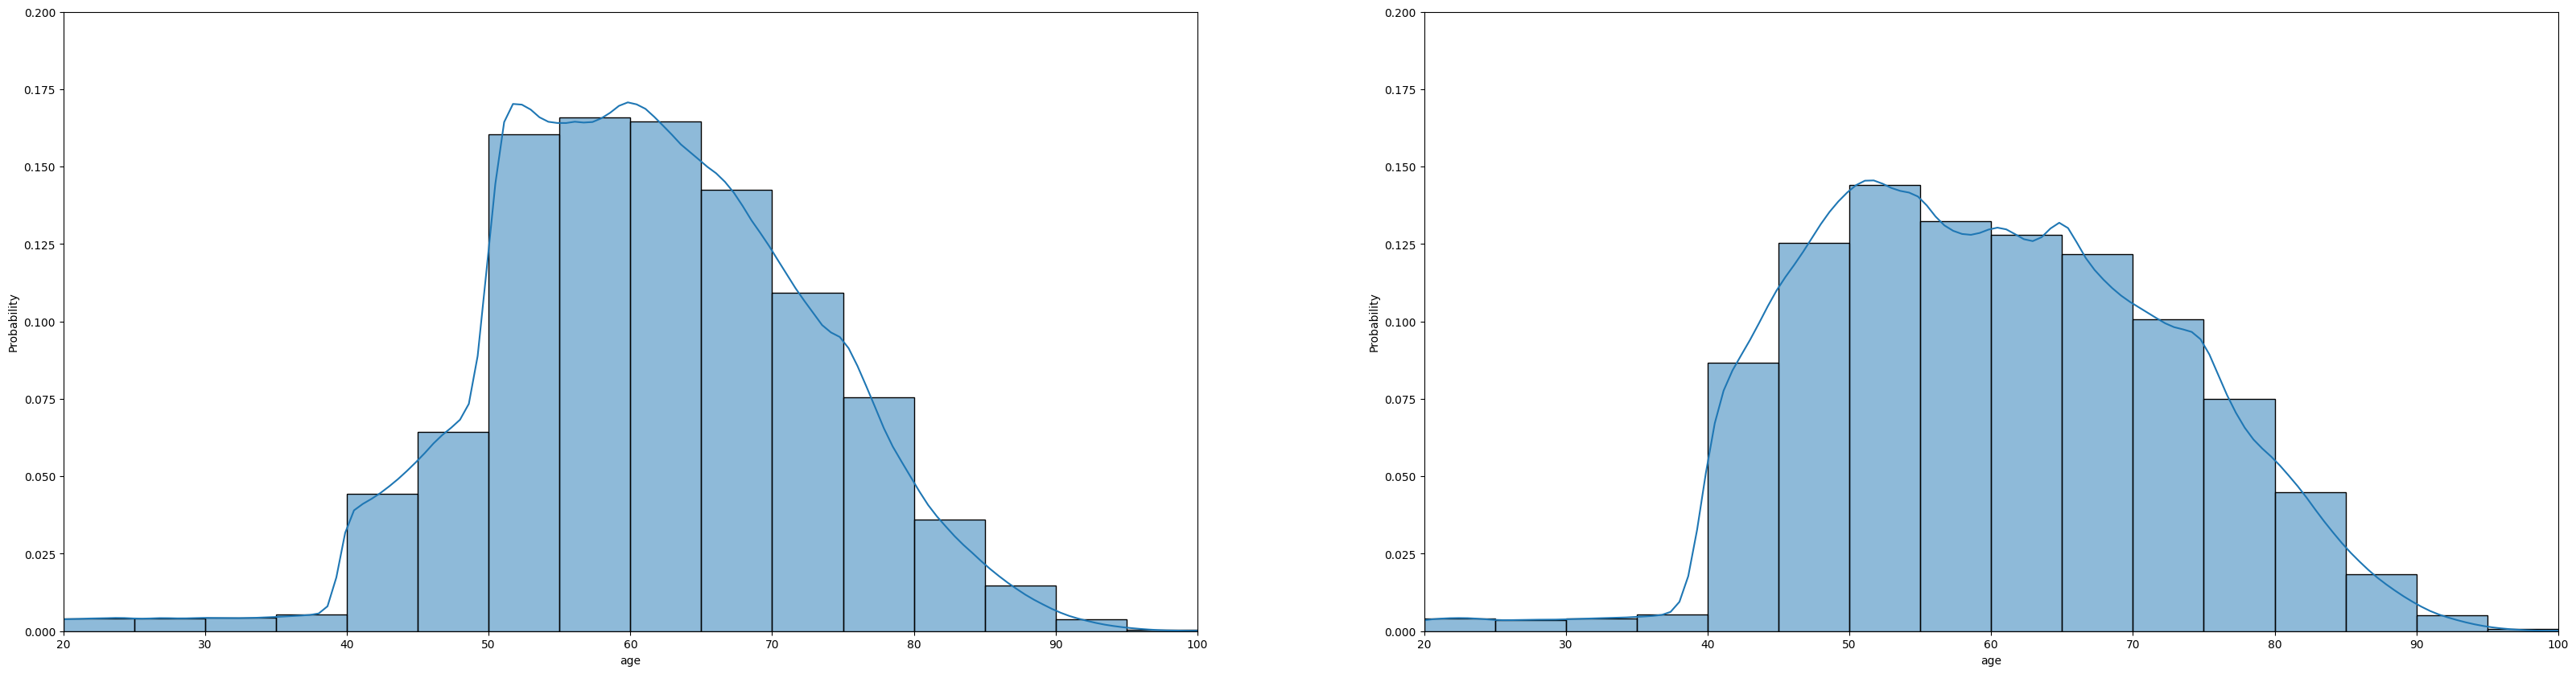

In [4]:
# 17 Specsacers AU and NZ Age Range Histplot

au_data = pd.read_csv(os.path.join(data_dir,'AU_screeners_data.csv'))
nz_data = pd.read_csv(os.path.join(data_dir,'NZ_screeners_data.csv'))

au_ages = au_data.assign(
    age=pd.to_numeric(au_data['testDateTime'].str[-4:]) - pd.to_numeric(au_data['birthday']).to_numpy()
)
nz_ages = nz_data.assign(
    age=pd.to_numeric(nz_data['testDateTime'].str[-4:]) - pd.to_numeric(nz_data['birthday']).to_numpy()
)

plt.figure(figsize=(40, 10))
plt.subplot(1, 2, 1)
sn.histplot(data=au_ages, x='age', kde=True, stat='probability', binwidth=5, binrange=[20, 100])
plt.ylim([0, 0.20])
plt.xlim([20, 100])
plt.subplot(1, 2, 2)
sn.histplot(data=nz_ages, x='age', kde=True, stat='probability', binwidth=5, binrange=[20, 100])
plt.ylim([0, 0.20])
plt.xlim([20, 100])

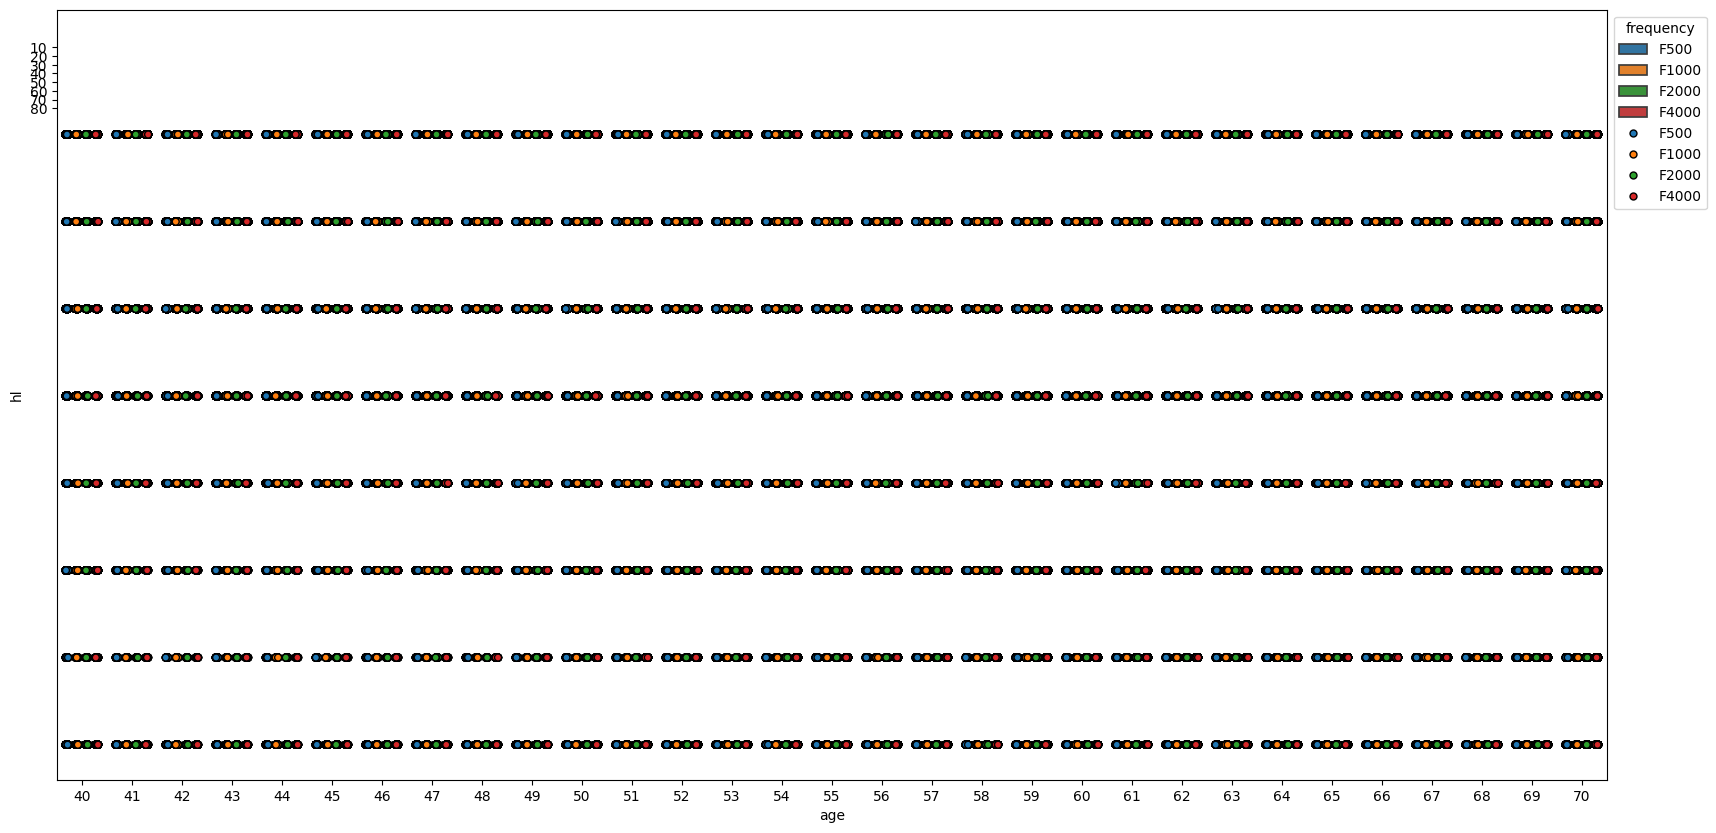

In [5]:
# 18 Specsavers Stripplot
au_ages_worse = au_data.assign(
    age=pd.to_numeric(au_data['testDateTime'].str[-4:]) - pd.to_numeric(au_data['birthday']).to_numpy()
)

mean_left = (au_ages_worse['hlLeft.freq500'] + au_ages_worse['hlLeft.freq1000'] + au_ages_worse['hlLeft.freq2000'] + au_ages_worse['hlLeft.freq4000']) / 4
mean_right = (au_ages_worse['hlRight.freq500'] + au_ages_worse['hlRight.freq1000'] + au_ages_worse['hlRight.freq2000'] + au_ages_worse['hlRight.freq4000']) / 4

au_right_worse = au_ages_worse[mean_left < mean_right]
drop_left = au_right_worse.columns.drop(list(au_right_worse.filter(regex='hlLeft')))
au_right = au_right_worse[drop_left].rename(
    columns={
        'hlRight.freq500': 'F500',
        'hlRight.freq1000': 'F1000',
        'hlRight.freq2000': 'F2000',
        'hlRight.freq4000': 'F4000'
    }
).assign(ear='right')

au_left_worse = au_ages_worse[mean_left >= mean_right]
drop_right = au_left_worse.columns.drop(list(au_right_worse.filter(regex='hlRight')))
au_left = au_left_worse[drop_right].rename(
    columns={
        'hlLeft.freq500': 'F500',
        'hlLeft.freq1000': 'F1000',
        'hlLeft.freq2000': 'F2000',
        'hlLeft.freq4000': 'F4000'
    }
).assign(ear='left')

au_worse = pd.concat([au_right, au_left], ignore_index=True).melt(
   id_vars=['testDateTime', 'birthday', 'age', 'ear'],
   value_vars=[
       'F500', 'F1000', 'F2000', 'F4000',
   ],
   var_name='frequency',
   value_name='hl'
)

# plt.figure()
# ax = sn.kdeplot(data=au_worse, x='age', y='hl', hue='frequency', alpha=.5, fill=True)
# sn.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1))

au_worse_old = au_worse[(au_worse['age'] >= 40) & (au_worse['age'] <= 70)]

plt.figure(figsize=(20, 10))
ax1 = sn.violinplot(data=au_worse_old, x='age', y='hl', hue='frequency', orient='h')
for violin in ax1.collections[::2]:
  violin.set_alpha(0.5)
ax2 = sn.stripplot(
    data=au_worse_old, x='age', y='hl', hue='frequency',
    edgecolor='black', size=5, dodge=True, jitter=True,
    linewidth=1, ax=ax1, zorder=0
)

sn.move_legend(ax2, 'upper left', bbox_to_anchor=(1, 1))

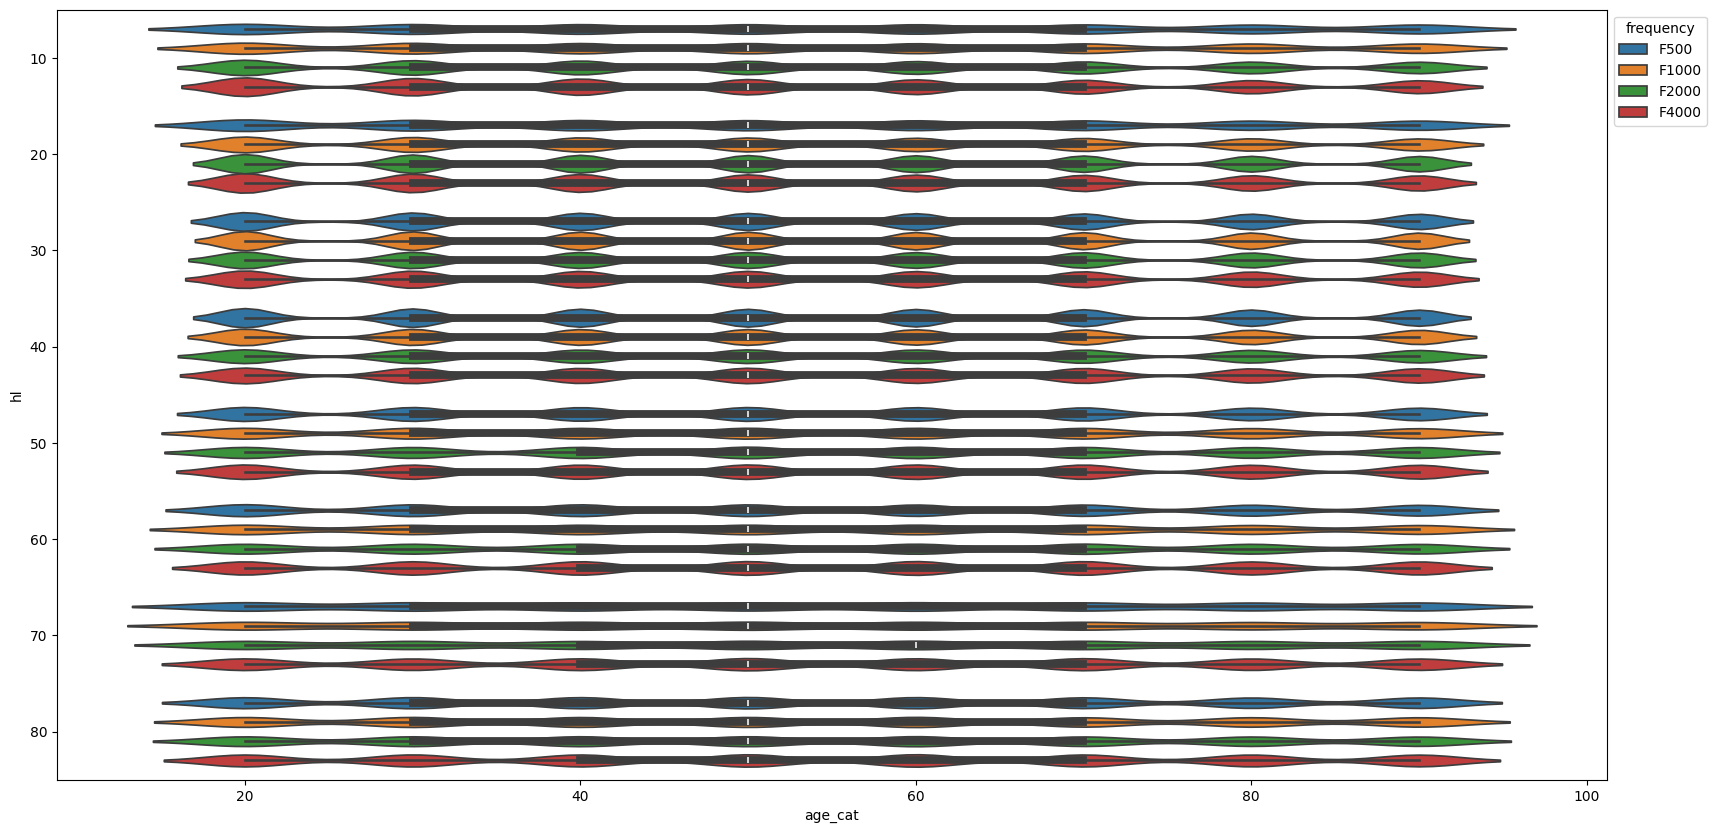

In [6]:
# 19 Specsaers AU and NZ Age Range Violinplot
# au_worse.assign(age_cat=((au_worse['age'] % 10) * 10).astype(int))
au_cat_age = au_worse.assign(age_cat=((au_worse['age'] % 10) * 10).astype(int))
# au_cat_age[(au_cat_age['age_cat'] > 10) & (au_cat_age['age_cat'] < 100)]
au_filtered = au_cat_age[(au_cat_age['age_cat'] > 10) & (au_cat_age['age_cat'] < 100)]

plt.figure(figsize=(20, 10))
ax = sn.violinplot(data=au_filtered, x='age_cat', y='hl', hue='frequency', orient='h')
sn.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1))

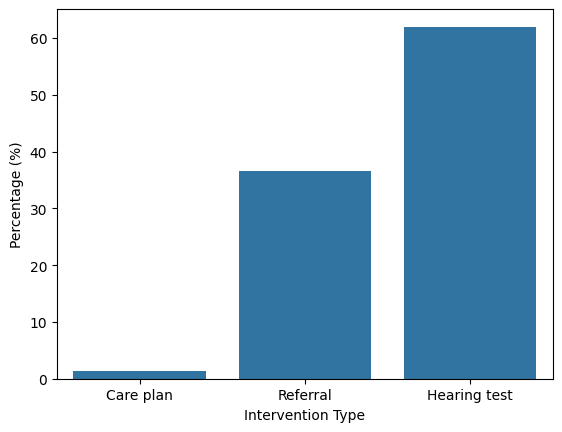

In [6]:


df = pd.read_excel(os.path.join(data_dir, 'first_intervention_type.xlsx'))

def create_bar_chart(df, x_label, y_label, title=""):
    sn.barplot(x=x_label, y=y_label, data=df)

perc_list = [100*num/(df['Total'].sum()) for num in df['Total'].tolist()]

new_df = pd.DataFrame({
  'Intervention Type': df['Intervention Type'],
  'Percentage (%)': perc_list
})

create_bar_chart(new_df, 'Intervention Type', 'Percentage (%)')

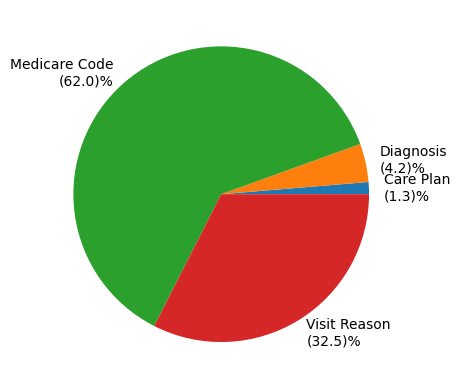

In [7]:
df = pd.read_excel(os.path.join(data_dir, 'intervention_origin.xlsx'))

def create_pie_chart(labels, sizes):
  fig, ax = plt.subplots()
  ax.pie(sizes, labels=labels)


perc_list = [100*num/(df['Total'].sum()) for num in df['Total'].tolist()]

combined = [f'{x}\n({round(y, 1)})%' for x, y in zip(df['Mapped'].to_list(), perc_list)]

create_pie_chart(combined, df['Total'])

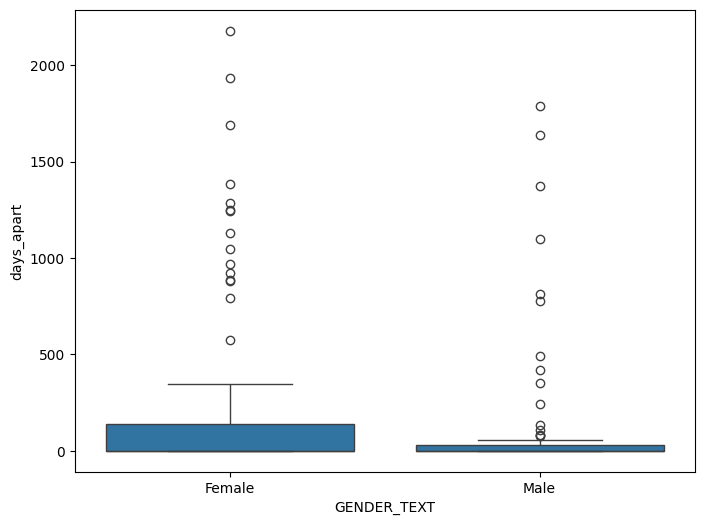

In [9]:
df = pd.read_excel(os.path.join(data_dir, 'intervention_day_count.xlsx'))

def create_box_plot(df, title, x_label, y_label):

  # Create the box plot
  plt.figure(figsize=(8, 6))  # Set the figure size
  sn.boxplot(x=x_label, y=y_label, data=df)

  # Add title and labels
  # plt.title(title)
  plt.xlabel(x_label)
  plt.ylabel(y_label)

create_box_plot(df, "Days from query to intervention", "GENDER_TEXT", "days_apart")

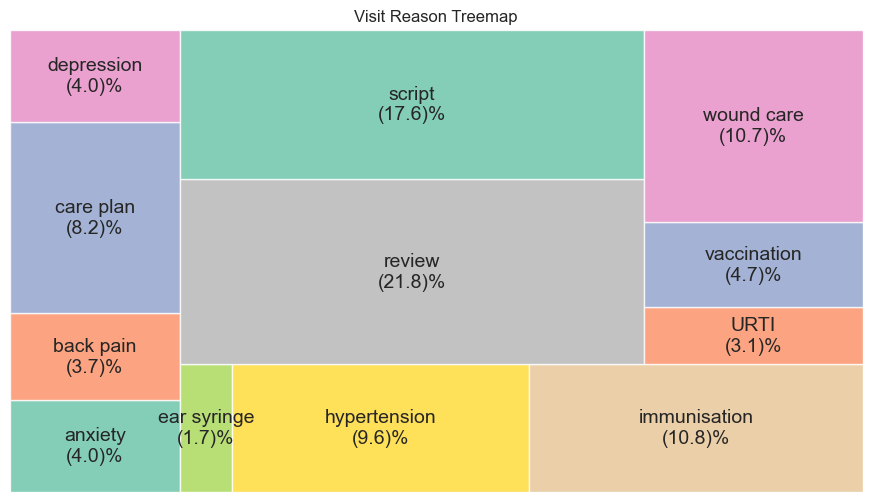

In [13]:


df = pd.read_excel(os.path.join(data_dir, 'pre_visit_reasons.xlsx'))

def create_tree_map(labels, frequencies, title):

  # Set Seaborn style
  sn.set(style="whitegrid")

  # Create the treemap
  plt.figure(figsize=(11, 6))
  squarify.plot(sizes=frequencies, label=labels, alpha=0.8, color=sn.color_palette('Set2'), 
              text_kwargs={'fontsize': 14}) 

  # Formatting
  plt.axis('off')  # No axes
  plt.title(title)

name_list = df['term'].to_list()
perc_list = df['perc']

combined = [f'{x}\n({round(y, 1)})%' for x, y in zip(name_list, perc_list)]

# save the file
labels = combined
frequencies = perc_list
create_tree_map(labels, frequencies, "Visit Reason Treemap")